# Lab 1: Introduction to EDA and ETL in Data Engineering
A data team typically contains several different roles:
- *data engineer*: maintain the infrastructure and workflows that allow data to move from raw sources into reliable, usable forms
- *data analysts*: build dashboards and business reports
- *data scientists*: explore patterns and develop predictive models
- *machine learning engineers*: deploy and maintain ML systems
- *product/ business teams*: make decisions based on data

In data engineering, raw data often arrives in messy or inconvenient formats. Before it can be used for analytics, machine learning, or reporting, we need to **inspect it, clean it, transform it, and store it** in a more usable form.

In this lab, you will be introduced to 2 key tasks in data engineering:
- **Exploratory Data Analysis (EDA)**: understanding the structure, quality, and patterns of a dataset
- **Extract, Transform, Load (ETL)**: building a simple pipeline to ingest, clean, and store data for downstream use

We will use a flight dataset as the main example and connect EDA with ETL as two parts of the same workflow.

## Exploratory Data Analysis (EDA)
EDA helps data engineers to understand
- what the data looks like
- whether the data is complete and trustworthy
- whether the schema is consistent
- whether downstream users can actually use it

A typical EDA process is involved with exploring
- size and shape
- column meanings and types
- missing values
- unusual values or outliers
- distributions
- relationships between variables

## Extract, Transform, Load (ETL)
ETL stands for:

- **Extract**: get data from one or more sources
- **Transform**: clean, standardize, enrich, and validate it
- **Load**: store it into a target system for later use

Typical workflow:
1. Extract raw data
2. Inspect structure and sample rows
3. Compute summary statistics
4. Visualize key variables
5. Identify data quality issues
6. Transform data
7. Save cleaned data for downstream use

## Exercise: Carrier On-Time Performance Dataset
### 1. Setup and data loading
Load the load with 29 columns out of 109:

[
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

And check the shape of the loaded data

In [102]:
import pandas as pd
import numpy as np

## Read data using 29 columns
use_cols = [
    # 29 columns out of 109
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "Reporting_Airline","Flight_Number_Reporting_Airline", 
    "Tail_Number", "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay", "Origin", "Dest",
    "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay"
]

DATA_DIR = '../datasets/'

## TO DO: read_csv()
airline = pd.read_csv(DATA_DIR + 'airline_2019.csv', usecols=use_cols)

## Check the shape of the loaded data
airline.shape

(76616, 29)

#### 1.1 Rename a few columns:
- "Reporting_Airline" -->  "UniqueCarrier"
- "Flight_Number_Reporting_Airline":"FlightNum"
- "Tail_Number":"TailNum"

A useful method here: `df.rename()` method: Original_Name:NewName
```python
df.rename(
    columns={
        
    },
    inplace=True
)
```

Column name convention:
 - **Snake Case Convention**: use underscores (_) to separate words
 - **Camel Case/ Pascal Case**: capitalize the first letter of each word

#### 1.2 Random sample 20k observations for further analysis 

In [103]:
## 1.1 Rename a few columns
airline.rename(columns={
    "Reporting_Airline": "UniqueCarrier",
    "Flight_Number_Reporting_Airline": "FlightNum",
    "Tail_Number": "TailNum"
}, inplace=True)

## 1.2 Random sampling for further analysis
airline_sample = airline.sample(n=20000)

### 2. Basic EDA

In [104]:
## Print first 5 rows to check how the data looks like
airline_sample.head(5)

,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,TailNum,FlightNum,Origin,Dest,CRSDepTime,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
44099,2019,10,19,6,OH,N555NN,5492,CLE,CLT,1719,...,0.0,106.0,107.0,76.0,430.0,NaN,NaN,NaN,NaN,NaN
53805,2019,5,21,2,B6,N653JB,1233,MCO,SJU,610,...,0.0,168.0,161.0,143.0,1189.0,NaN,NaN,NaN,NaN,NaN
31824,2019,9,26,4,UA,N63820,624,SFO,ORD,1040,...,0.0,262.0,243.0,215.0,1846.0,NaN,NaN,NaN,NaN,NaN
23588,2019,10,20,7,HA,N484HA,228,HNL,KOA,1017,...,0.0,48.0,43.0,27.0,163.0,NaN,NaN,NaN,NaN,NaN
47627,2019,12,10,2,WN,N488WN,1017,SAN,PHX,1715,...,0.0,70.0,70.0,52.0,304.0,NaN,NaN,NaN,NaN,NaN


In [105]:
## Get descriptive statistics and missing value percentage for each column
def get_info(pd_frame):
    # generate descriptive statistics (like count, mean, std, min, etc.) for numeric columns
    res = pd_frame.describe().transpose()
    # calculate the missing percentage for each variable
    res['missing_percent'] = [(pd_frame.shape[0] - res.loc[ind, 'count'])/pd_frame.shape[0] for ind in res.index]
    # 
    res['unique_val'] = [len(pd_frame.loc[:,ind].value_counts()) for ind in res.index]
    res['var_type'] = ['Continuous' if res.loc[ind, 'unique_val'] >=100 else 'Categorical' for ind in res.index]
    return res
    

In [106]:
airline_info = get_info(airline_sample)
airline_info

,count,mean,std,min,25%,50%,75%,max,missing_percent,unique_val,var_type
Year,20000.0,2019.000000,0.000000,2019.0,2019.0,2019.0,2019.00,2019.0,0.00000,1,Categorical
Month,20000.0,6.523900,3.402265,1.0,4.0,7.0,9.00,12.0,0.00000,12,Categorical
DayofMonth,20000.0,15.709750,8.731215,1.0,8.0,16.0,23.00,31.0,0.00000,31,Categorical
DayOfWeek,20000.0,3.957000,2.000713,1.0,2.0,4.0,6.00,7.0,0.00000,7,Categorical
FlightNum,20000.0,2562.657850,1803.914962,1.0,1039.0,2153.0,3905.25,7437.0,0.00000,5677,Continuous
CRSDepTime,20000.0,1327.675650,493.823080,5.0,910.0,1318.0,1740.00,2359.0,0.00000,1150,Continuous
DepTime,19644.0,1331.667328,508.295777,1.0,910.0,1324.0,1748.00,2400.0,0.01780,1247,Continuous
DepDelay,19644.0,10.913867,52.143954,-42.0,-5.0,-2.0,7.00,1252.0,0.01780,369,Continuous
TaxiOut,19626.0,17.410527,10.007476,1.0,11.0,15.0,20.00,168.0,0.01870,108,Continuous
TaxiIn,19611.0,7.739687,6.074349,1.0,4.0,6.0,9.00,122.0,0.01945,69,Categorical


### 3. Visualization and pattern finding
In this part, you need to:
#### 3.1 Visualize the value distribution of each column
#### 3.2 Calculate the missing value percentage of each column
#### 3.3 Visualize the #observations across DayofMonth & DayofWeek
#### 3.4 Visualize arrival and departure delays distribution
`sns.boxplot()` might be a useful function here to visualize spread, outliers, and quartiles.
```python
sns.boxplot(data=your_dataframe, x='categorical_column', y='numerical_column')
```

`sns.countplot()` will displays the count of observations for each category in a categorical variable.
```python
sns.countplot(data=your_dataframe, x='categorical_column')
```

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns


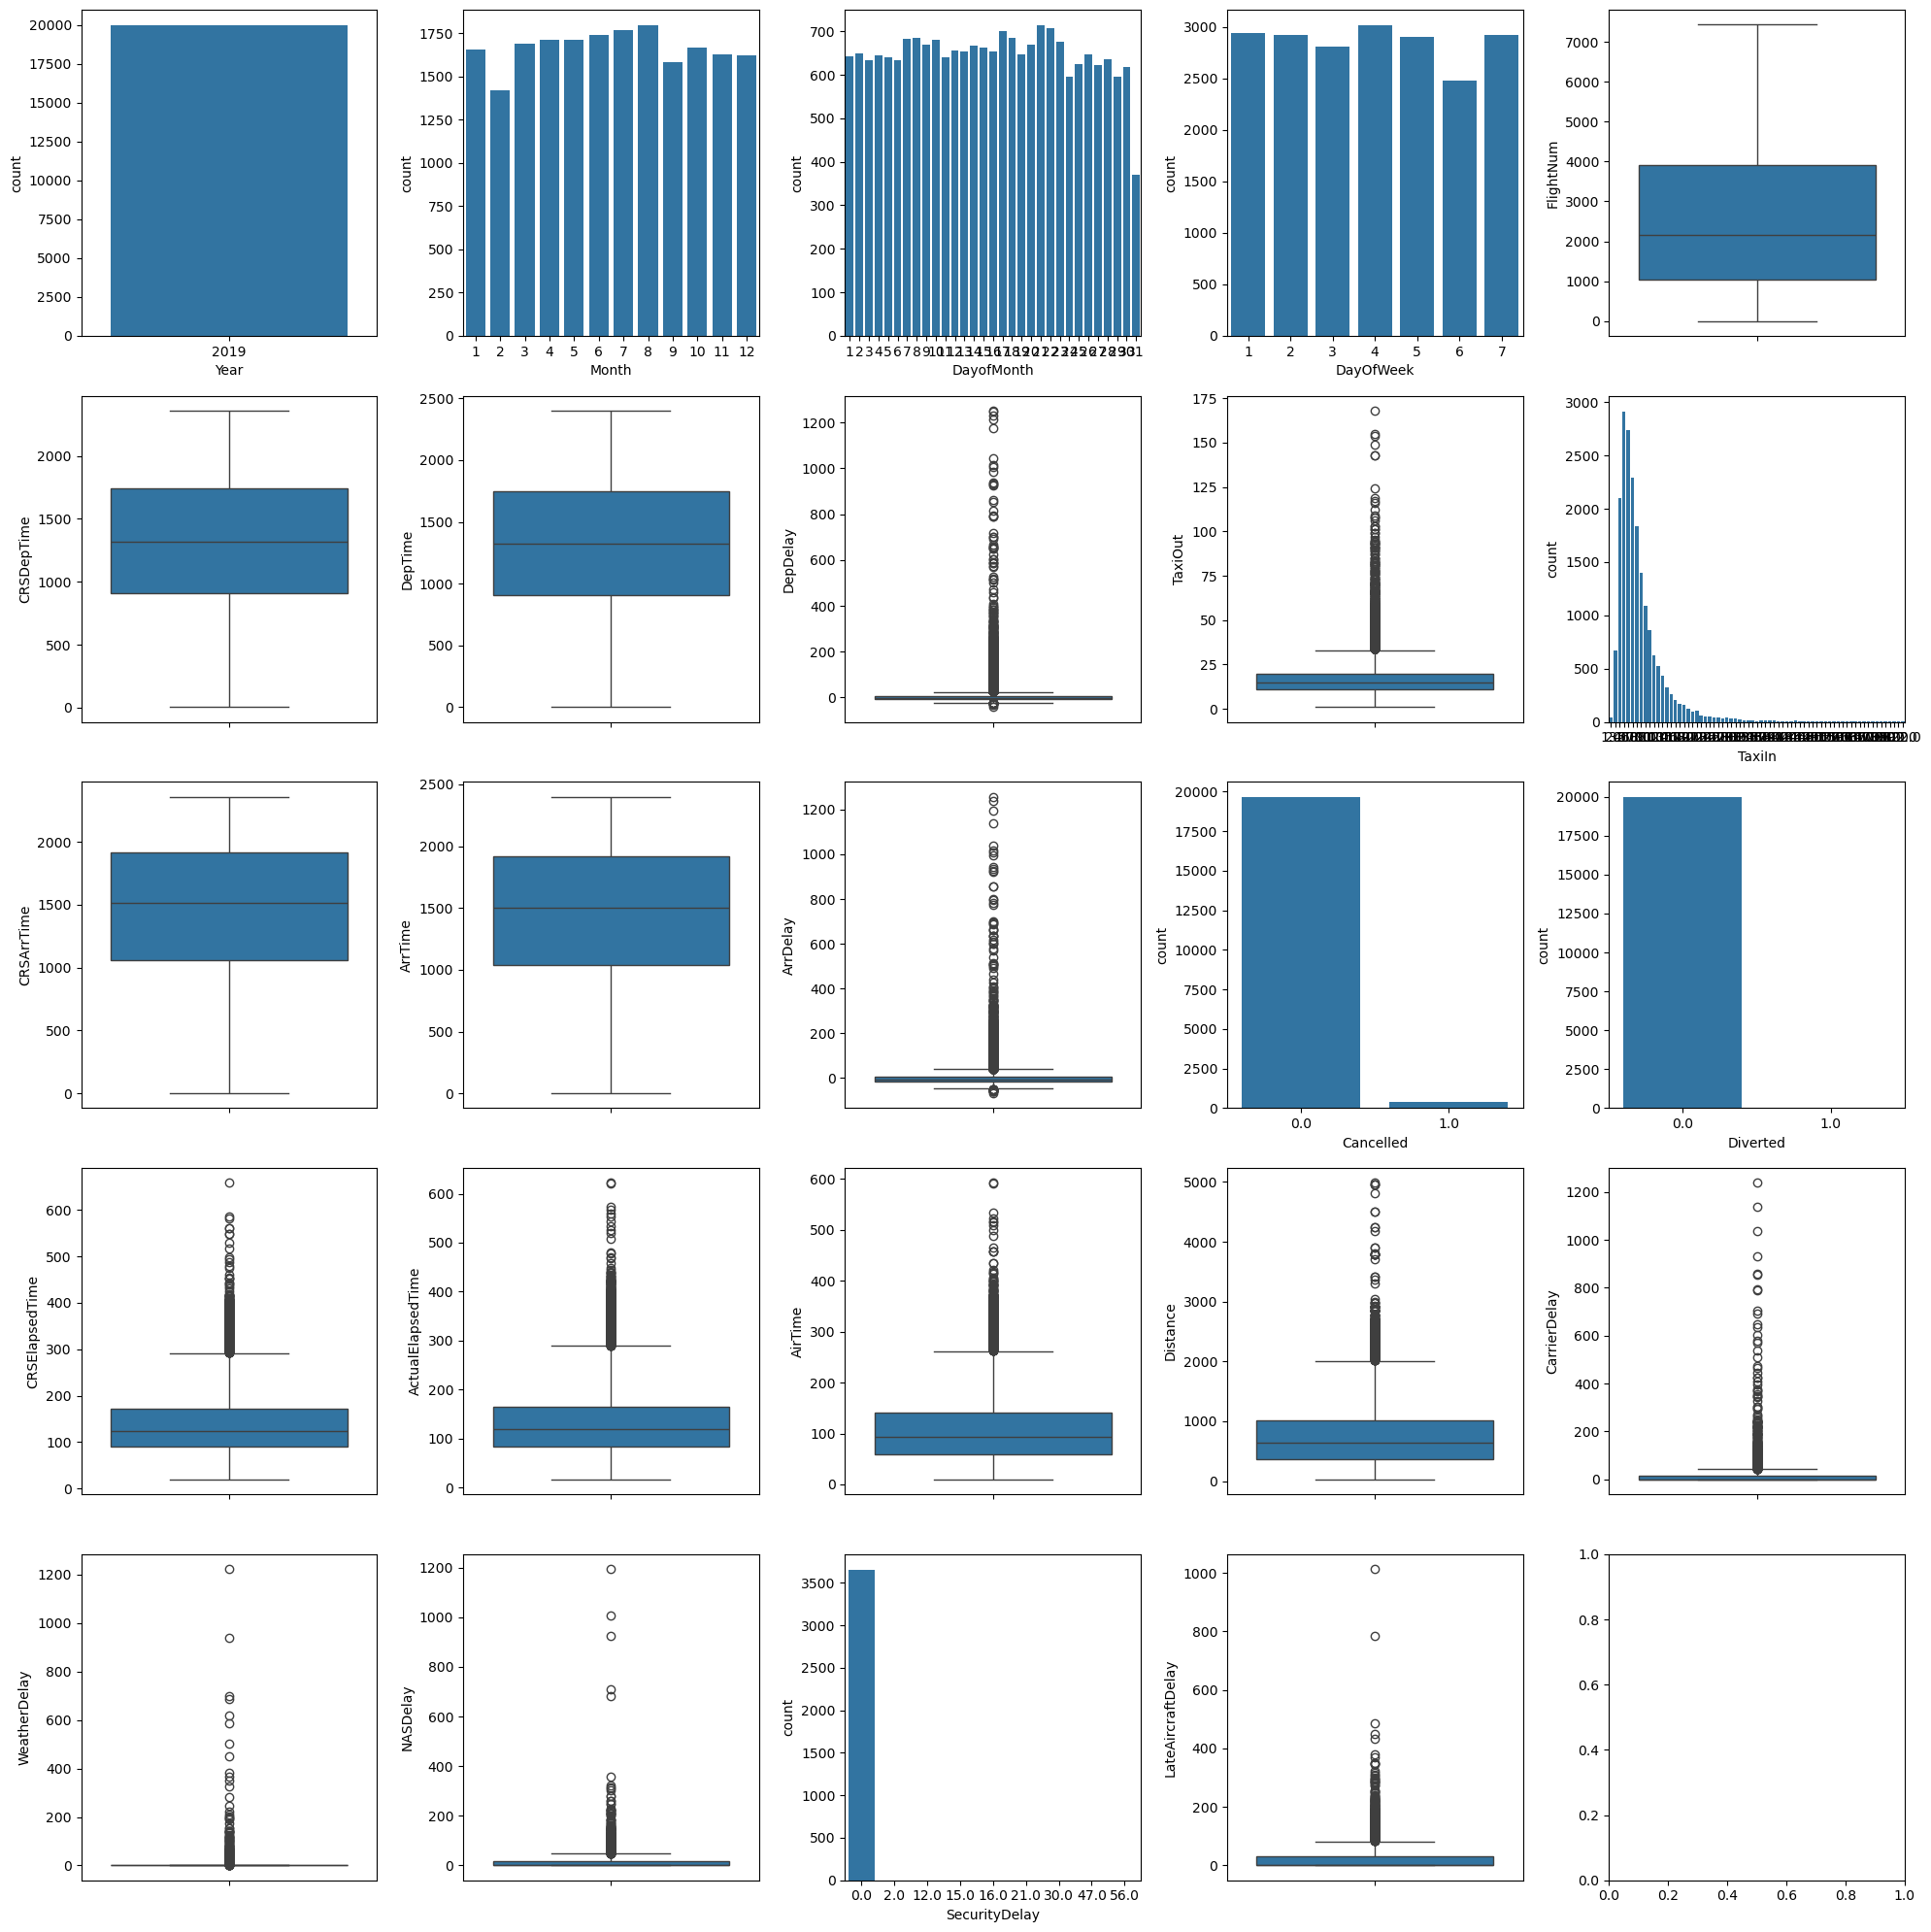

In [108]:
## 3.1 Visualize the value distribution of each column
## If the value type is continuous, we will use boxplot
## If the value type is discrete, we will use bar chart

# omit non-numeric columns since we're only looking at continuous and discrete variables
airline_num = airline_sample.select_dtypes(include='number')

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))

for ind, col in enumerate(airline_num.columns):
    ax = axes[ind//5, ind%5] # determine the position of the subplot
    
    if airline_info.loc[col, 'var_type'] == 'Continuous':
        sns.boxplot(y=col, data=airline_num, ax=ax) # no x variable is needed because we only want to see the value distribution of the column
    else: # discrete variable
        sns.countplot(x=col, data=airline_num, ax=ax) # use countplot to output bar chart

plt.tight_layout()
plt.show()

In [109]:
## 3.2 Calculate the missing value percentage of each column
airline_info['missing_percent']

Year                 0.00000
Month                0.00000
DayofMonth           0.00000
DayOfWeek            0.00000
FlightNum            0.00000
CRSDepTime           0.00000
DepTime              0.01780
DepDelay             0.01780
TaxiOut              0.01870
TaxiIn               0.01945
CRSArrTime           0.00000
ArrTime              0.01945
ArrDelay             0.02105
Cancelled            0.00000
Diverted             0.00000
CRSElapsedTime       0.00000
ActualElapsedTime    0.02105
AirTime              0.02105
Distance             0.00000
CarrierDelay         0.81675
WeatherDelay         0.81675
NASDelay             0.81675
SecurityDelay        0.81675
LateAircraftDelay    0.81675
Name: missing_percent, dtype: float64

Text(0.5, 0, 'Day of Month')

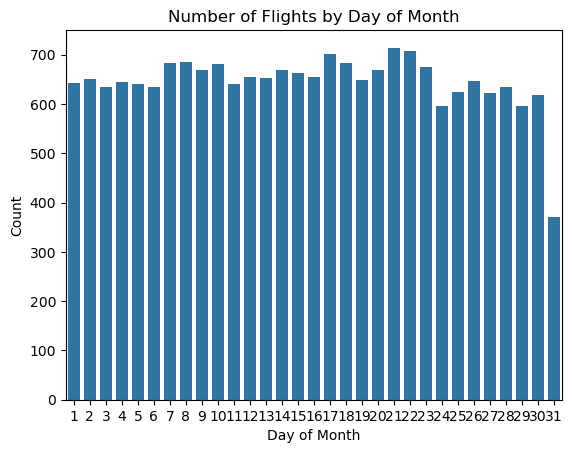

In [110]:
## 3.3 Count number of flights in different DayofMonth and DayOfWeek

## Visualize with Barchart

# day of month
gmonth = sns.countplot(x='DayofMonth', data=airline_sample)
gmonth.set_title('Number of Flights by Day of Month')
gmonth.set_ylabel('Count')
gmonth.set_xlabel('Day of Month')

Text(0.5, 0, 'Day of Week')

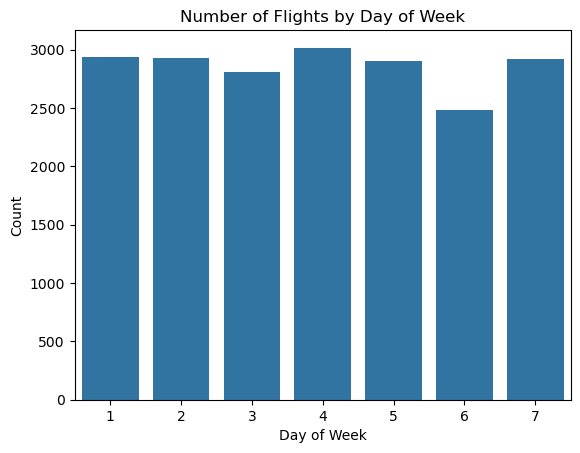

In [111]:
# day of week
gweek = sns.countplot(x='DayOfWeek', data=airline_sample)
gweek.set_title('Number of Flights by Day of Week')
gweek.set_ylabel('Count')
gweek.set_xlabel('Day of Week')

Text(0, 0.5, 'Frequency')

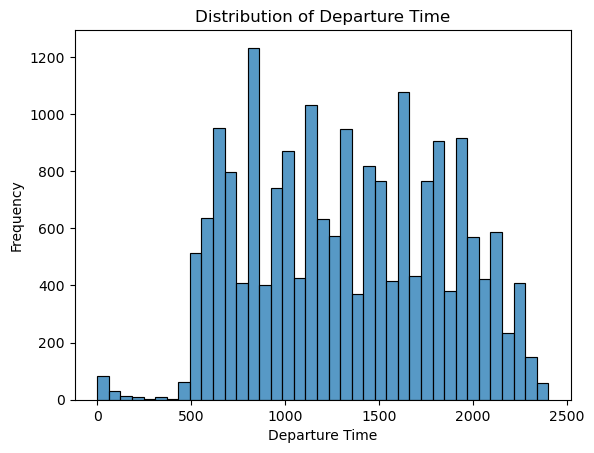

In [112]:
## 3.4.1 Histogram of Departure Time
sns.histplot(x='DepTime', data=airline_sample)
plt.title('Distribution of Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Frequency')

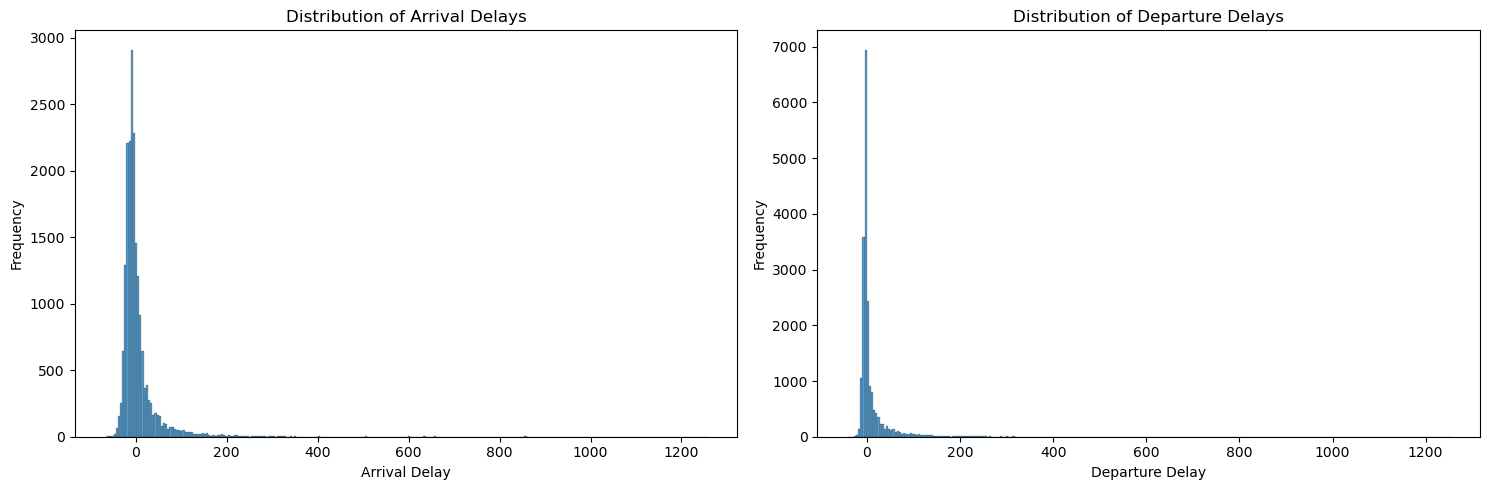

In [113]:
## 3.4.2 Histogram of arrival and departure delays

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# arrival delays
garrdelay = sns.histplot(x='ArrDelay', data=airline_sample, ax=axes[0])
garrdelay.set_title('Distribution of Arrival Delays')
garrdelay.set_xlabel('Arrival Delay')
garrdelay.set_ylabel('Frequency')

# departure delays
gdepdelay = sns.histplot(x='DepDelay', data=airline_sample, ax=axes[1])
gdepdelay.set_title('Distribution of Departure Delays')
gdepdelay.set_xlabel('Departure Delay')
gdepdelay.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

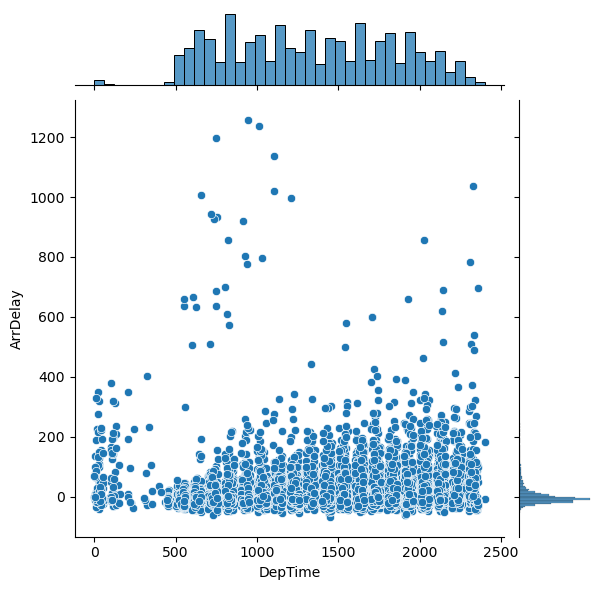

In [114]:
## 3.5.1 bivariate analysis: arrival delay vs departure time
# plot of arrival delay vs departure time Scatterplot
sns.jointplot(x='DepTime', y='ArrDelay', data=airline_sample)

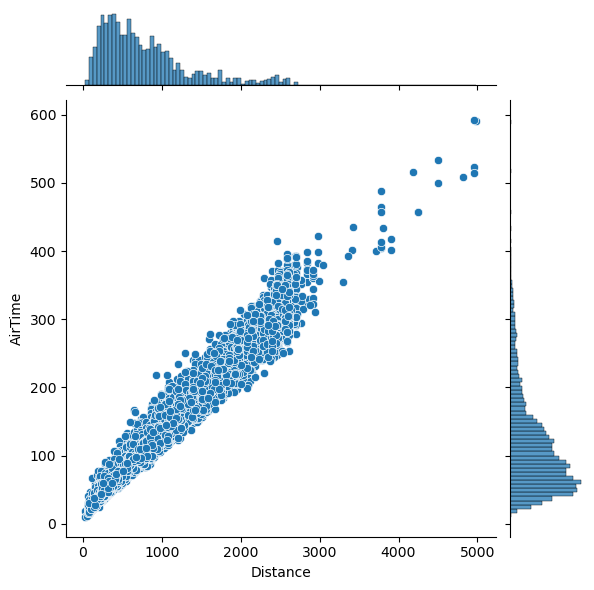

In [115]:
## 3.5.2 bivariate analysis: distance and airtimes
sns.jointplot(x='Distance', y='AirTime', data=airline_sample)

### 4. Feature engineering and cleaning

In [116]:
## 4.1 creating a categorical column for weekday
weekday_map = {1: 'Monday',
               2: 'Tuesday',
               3: 'Wednesday',
               4: 'Thursday',
               5: 'Friday',
               6: 'Saturday',
               7: 'Sunday'}

airline['Weekday'] = airline['DayOfWeek'].map(weekday_map)
airline[['DayOfWeek', 'Weekday']].head()

,DayOfWeek,Weekday
0,2,Tuesday
1,1,Monday
2,3,Wednesday
3,3,Wednesday
4,3,Wednesday


In [117]:
## 4.2 first use a max(0,x) transform to get rid of negative values
## then create a new column using the log(1+x)

# remove negative values in arrdelay and depdelay
airline['LogArrDelay'] = airline['ArrDelay'].apply(lambda x: max(0, x))
airline['LogDepDelay'] = airline['DepDelay'].apply(lambda x: max(0, x))

# log transform
airline['LogArrDelay'] = np.log1p(airline['LogArrDelay']) # uses the natural log
airline['LogDepDelay'] = np.log1p(airline['LogDepDelay'])

airline[['ArrDelay', 'LogArrDelay', 'DepDelay', 'LogDepDelay']].head()

,ArrDelay,LogArrDelay,DepDelay,LogDepDelay
0,214.0,5.370638,221.0,5.402677
1,-3.0,0.000000,-4.0,0.000000
2,-6.0,0.000000,0.0,0.000000
3,-6.0,0.000000,0.0,0.000000
4,-21.0,0.000000,-5.0,0.000000


In [118]:
## 4.3 Create a new column called 'DecimalDepTime', which convert 'CRSDepTime' (HHMM format) into decimal house
## For example: 1330 --> 13.5; 9:45 --> 9.75
airline['DecimalDepTime'] = airline['CRSDepTime'].apply(lambda x: (x // 100) + ((x % 100) / 60))
airline = airline.round({'DecimalDepTime': 2}) # round to 2 decimal places

airline[['CRSDepTime', 'DecimalDepTime']].head()


,CRSDepTime,DecimalDepTime
0,1950,19.83
1,1204,12.07
2,1605,16.08
3,1055,10.92
4,1714,17.23


In [119]:
## 4.4 Create a new column 'speed', which is equal distance/AirTime. Make sure the unit of column is Miles Per Hour (mph)
airline['Speed'] = airline['Distance'] / (airline['AirTime'] / 60) # convert airtime from minutes to hours

airline[['Distance', 'AirTime', 'Speed']].head()

,Distance,AirTime,Speed
0,192.0,35.0,329.142857
1,1010.0,149.0,406.711409
2,245.0,52.0,282.692308
3,674.0,97.0,416.907216
4,270.0,44.0,368.181818


Text(0, 0.5, 'Speed (mph)')

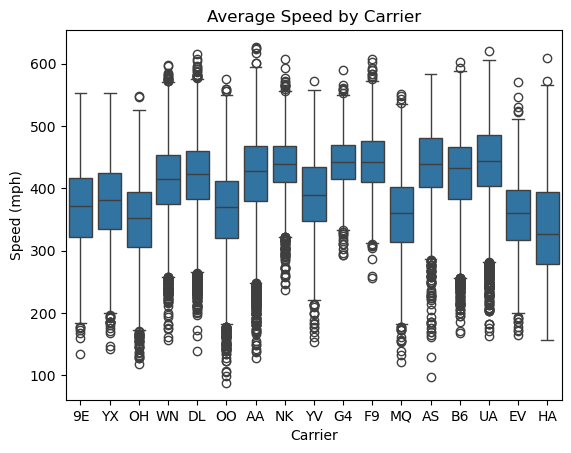

In [120]:
## boxplots of average speeds
sns.boxplot(x='UniqueCarrier', y='Speed', data=airline)
plt.title('Average Speed by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Speed (mph)')

In [121]:
#### 4.5 Filter flights with speeds greater than 650 mph and calculate their proportion in the dataset.
fast_flights = airline[airline['Speed'] > 650]
fast_flights.shape[0] / airline.shape[0]

0.0

### 5. Save transformed data
This corresponds to the "Load" part in ETL

Regarding the saved file format
- raw CSV is good for sharing
- Parquet is better for analytics workflows

You can choose whatever format you like to save the transformed data in this exercise.

In [122]:
## Save transformed data
# parquet format
airline.to_parquet(DATA_DIR + 'airline_transformed.parquet')